In [ ]:
# Cell 1: Setup, Imports, Reproducibility, and Drive Mounting
import os
import random
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_fscore_support
)

# Install required packages
!pip install timm imagehash kagglehub -q

import timm
import imagehash
import kagglehub

# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Create project directory in Drive
PROJECT_DIR = '/content/drive/MyDrive/batik_classification_v2'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/splits', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/figures', exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"  - checkpoints/  (model weights)")
print(f"  - results/      (metrics JSON files)")
print(f"  - splits/       (CSV files for GitHub)")
print(f"  - figures/      (plots)")

# ============================================================
# DEVICE AND REPRODUCIBILITY
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.cuda.is_available()}")

def set_seed(seed):
    """Set seed for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Seeds for multi-run statistical analysis
SEEDS = [42, 123, 456]
print(f"\nSeeds for statistical analysis: {SEEDS}")

# ============================================================
# CONFIGURATION
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 10
NUM_EPOCHS = 20      # reduced from 30 — converges earlier
PATIENCE = 7         # reduced from 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
USE_AMP = True       # mixed precision for speed

print(f"\n--- Configuration ---")
print(f"  Image size:     {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Num classes:    {NUM_CLASSES}")
print(f"  Max epochs:     {NUM_EPOCHS}")
print(f"  Patience:       {PATIENCE}")
print(f"  Learning rate:  {LEARNING_RATE}")
print(f"  Weight decay:   {WEIGHT_DECAY}")
print(f"  Mixed precision: {USE_AMP}")

print(f"\n--- Library Versions ---")
print(f"  PyTorch:  {torch.__version__}")
print(f"  timm:     {timm.__version__}")
print(f"  imagehash: {imagehash.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.5 MB/s eta 0:00:00
Mounted at /content/drive
Project directory: /content/drive/MyDrive/batik_classification_v2
  - checkpoints/  (model weights)
  - results/      (metrics JSON files)
  - splits/       (CSV files for GitHub)
  - figures/      (plots)

Device: cuda
GPU: NVIDIA L4
CUDA: True

Seeds for statistical analysis: [42, 123, 456]

--- Configuration ---
  Image size:     224x224
  Batch size:     32
  Num classes:    10
  Max epochs:     20
  Patience:       7
  Learning rate:  0.0001
  Weight decay:   0.0001
  Mixed precision: True

--- Library Versions ---
  PyTorch:  2.11.0+cu128
  timm:     1.0.27
  imagehash: 4.3.2


In [ ]:
# Cell 2: Download Dataset + Cache to Drive
DRIVE_DATA_DIR = f'{PROJECT_DIR}/dataset'

# Check if dataset already cached
if os.path.exists(DRIVE_DATA_DIR) and len(os.listdir(DRIVE_DATA_DIR)) > 0:
    print(f"Dataset already cached in Drive at: {DRIVE_DATA_DIR}")
    data_path = DRIVE_DATA_DIR
else:
    print("Downloading dataset from Kaggle (12GB, ~14 min)...")
    data_path = kagglehub.dataset_download("edywinarno/semarang-batik-dataset")
    print(f"Downloaded to: {data_path}")

    # Copy to Drive for future sessions
    print(f"\nCopying to Drive for caching (~5 min)...")
    !mkdir -p "{DRIVE_DATA_DIR}"
    !cp -r "{data_path}"/* "{DRIVE_DATA_DIR}/"
    data_path = DRIVE_DATA_DIR
    print(f"Cached at: {DRIVE_DATA_DIR}")

# ============================================================
# EXPLORE DATASET STRUCTURE
# ============================================================
print("\n--- Class Summary ---")
class_info = {}
for item in sorted(os.listdir(data_path)):
    item_path = os.path.join(data_path, item)
    if os.path.isdir(item_path):
        imgs = [f for f in os.listdir(item_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if imgs:
            class_info[item] = {'path': item_path, 'count': len(imgs)}
            print(f"  {item}: {len(imgs)} images")

print(f"\nTotal classes: {len(class_info)}")
print(f"Total images: {sum(v['count'] for v in class_info.values())}")

Dataset already cached in Drive at: /content/drive/MyDrive/batik_classification_v2/dataset

--- Class Summary ---
  Batik Cap Asem Arang: 300 images
  Batik Cap Asem Sinom: 300 images
  Batik Cap Asem Warak: 308 images
  Batik Cap Blekok: 300 images
  Batik Cap Blekok Warak: 300 images
  Batik Cap Gambang Semarangan: 308 images
  Batik Cap Kembang Sepatu: 300 images
  Batik Cap Semarangan: 304 images
  Batik Cap Tugu Muda: 300 images
  Batik Cap Warak Beras Utah: 300 images

Total classes: 10
Total images: 3020


In [ ]:
# Cell 3: Near-Duplicate Detection using Pretrained ResNet Features
from torchvision import transforms as T
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

# Check if duplicate analysis already cached
DUPLICATE_CACHE = f'{PROJECT_DIR}/duplicate_analysis.json'

if os.path.exists(DUPLICATE_CACHE):
    print(f"Loading cached duplicate analysis from Drive...")
    with open(DUPLICATE_CACHE, 'r') as f:
        cached = json.load(f)
    class_source_groups = {cls: [grp for grp in groups] for cls, groups in cached.items()}
    total_sources = sum(len(g) for g in class_source_groups.values())
    print(f"Loaded {total_sources} source groups across {len(class_source_groups)} classes")
else:
    print("Running near-duplicate analysis (this takes ~5 min)...")

    # Load pretrained ResNet-18 as feature extractor
    feat_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    feat_model = nn.Sequential(*list(feat_model.children())[:-1])
    feat_model = feat_model.to(device).eval()

    preprocess = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def extract_features(img_path):
        img = Image.open(img_path).convert('RGB')
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = feat_model(tensor).squeeze().cpu().numpy()
        return feat

    COSINE_THRESHOLD = 0.3
    print(f"\n{'Class':<40} {'Total':>6} {'Sources':>8} {'Avg/Src':>8} {'Max/Src':>8}")
    print("-" * 75)

    class_source_groups = {}

    for cls_name, info in tqdm(sorted(class_info.items()), desc="Analyzing classes"):
        cls_path = info['path']
        img_files = sorted([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        filepaths = [os.path.join(cls_path, f) for f in img_files]

        # Extract features
        features = []
        for fp in filepaths:
            features.append(extract_features(fp))
        features = np.array(features)

        # Hierarchical clustering
        if len(features) > 1:
            distances = pdist(features, metric='cosine')
            Z = linkage(distances, method='average', metric='cosine')
            cluster_labels = fcluster(Z, t=COSINE_THRESHOLD, criterion='distance')
        else:
            cluster_labels = [1]

        groups = defaultdict(list)
        for fp, label in zip(filepaths, cluster_labels):
            groups[label].append(fp)
        groups = list(groups.values())

        sizes = [len(g) for g in groups]
        print(f"  {cls_name:<38} {len(filepaths):>6} {len(groups):>8} {np.mean(sizes):>8.1f} {max(sizes):>8}")

        class_source_groups[cls_name] = groups

    # Cache to Drive
    cache_data = {cls: groups for cls, groups in class_source_groups.items()}
    with open(DUPLICATE_CACHE, 'w') as f:
        json.dump(cache_data, f, indent=2)
    print(f"\nDuplicate analysis cached to: {DUPLICATE_CACHE}")

# Final summary
total_images = sum(info['count'] for info in class_info.values())
total_sources = sum(len(g) for g in class_source_groups.values())
print(f"\n--- Summary ---")
print(f"Total images: {total_images}")
print(f"Unique source groups: {total_sources}")
print(f"Average images per source: {total_images / total_sources:.1f}")

Loading cached duplicate analysis from Drive...
Loaded 18 source groups across 10 classes

--- Summary ---
Total images: 3020
Unique source groups: 18
Average images per source: 167.8


In [ ]:
# Cell 4: Create Splits — 80/20 (no validation), Save CSVs for GitHub
set_seed(42)  # fixed seed for reproducible splits

class_names = sorted(class_source_groups.keys())
label_to_idx = {name: idx for idx, name in enumerate(class_names)}

# ============================================================
# NAIVE SPLIT (random 80/20)
# ============================================================
naive_train_files = []
naive_test_files = []

for cls_name, info in sorted(class_info.items()):
    cls_path = info['path']
    img_files = sorted([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    filepaths = [os.path.join(cls_path, f) for f in img_files]
    labels = [cls_name] * len(filepaths)

    train_fps, test_fps, train_lbls, test_lbls = train_test_split(
        filepaths, labels, test_size=0.2, random_state=42, stratify=labels
    )
    naive_train_files.extend(list(zip(train_fps, train_lbls)))
    naive_test_files.extend(list(zip(test_fps, test_lbls)))

print(f"NAIVE SPLIT: Train={len(naive_train_files)}, Test={len(naive_test_files)}")

# ============================================================
# CORRECTED SPLIT (group-aware 80/20)
# ============================================================
corrected_train_files = []
corrected_test_files = []

print(f"\n{'Class':<35} {'Src':>4} {'Tr Src':>7} {'Te Src':>7} {'Tr Img':>7} {'Te Img':>7} {'Note'}")
print("-" * 90)

for cls_name in class_names:
    groups = class_source_groups[cls_name]
    n_groups = len(groups)

    if n_groups == 1:
        # Only 1 source: split images from this single group 80/20
        all_fps = groups[0].copy()
        random.seed(42)
        random.shuffle(all_fps)
        split_idx = int(len(all_fps) * 0.8)
        train_fps = all_fps[:split_idx]
        test_fps = all_fps[split_idx:]

        corrected_train_files.extend([(fp, cls_name) for fp in train_fps])
        corrected_test_files.extend([(fp, cls_name) for fp in test_fps])
        print(f"  {cls_name:<33} {n_groups:>4} {'1*':>7} {'1*':>7} {len(train_fps):>7} {len(test_fps):>7} ⚠️ single src")

    elif n_groups == 2:
        # 2 sources: larger group -> train, smaller group -> test
        sorted_idx = sorted(range(n_groups), key=lambda i: len(groups[i]), reverse=True)
        train_group = sorted_idx[0]
        test_group = sorted_idx[1]

        train_fps = groups[train_group]
        test_fps = groups[test_group]

        corrected_train_files.extend([(fp, cls_name) for fp in train_fps])
        corrected_test_files.extend([(fp, cls_name) for fp in test_fps])
        print(f"  {cls_name:<33} {n_groups:>4} {'1':>7} {'1':>7} {len(train_fps):>7} {len(test_fps):>7}")

    else:
        # 3+ sources: 80/20 split at group level
        random.seed(42)
        group_indices = list(range(n_groups))
        random.shuffle(group_indices)
        n_test = max(1, round(n_groups * 0.2))

        test_idx = group_indices[:n_test]
        train_idx = group_indices[n_test:]

        train_fps = [fp for i in train_idx for fp in groups[i]]
        test_fps = [fp for i in test_idx for fp in groups[i]]

        corrected_train_files.extend([(fp, cls_name) for fp in train_fps])
        corrected_test_files.extend([(fp, cls_name) for fp in test_fps])
        print(f"  {cls_name:<33} {n_groups:>4} {len(train_idx):>7} {n_test:>7} {len(train_fps):>7} {len(test_fps):>7}")

print("-" * 90)
print(f"  {'TOTAL':<33} {'':>4} {'':>7} {'':>7} {len(corrected_train_files):>7} {len(corrected_test_files):>7}")

# Verify no overlap
train_set = set(fp for fp, _ in corrected_train_files)
test_set = set(fp for fp, _ in corrected_test_files)
print(f"\nCorrected split file overlap (should be 0): {len(train_set & test_set)}")

# ============================================================
# SAVE SPLITS AS CSV FOR GITHUB REPRODUCIBILITY
# ============================================================
def save_split_csv(files, filename):
    rows = []
    for fp, lbl in files:
        # Save only the relative path (class_folder/image.jpg) for portability
        rel_path = '/'.join(fp.split('/')[-2:])
        rows.append({'filename': rel_path, 'class': lbl})
    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    return df

splits_dir = f'{PROJECT_DIR}/splits'
save_split_csv(naive_train_files, f'{splits_dir}/naive_train.csv')
save_split_csv(naive_test_files, f'{splits_dir}/naive_test.csv')
save_split_csv(corrected_train_files, f'{splits_dir}/corrected_train.csv')
save_split_csv(corrected_test_files, f'{splits_dir}/corrected_test.csv')

print(f"\n✓ Splits saved to: {splits_dir}/")
print(f"  - naive_train.csv ({len(naive_train_files)} images)")
print(f"  - naive_test.csv ({len(naive_test_files)} images)")
print(f"  - corrected_train.csv ({len(corrected_train_files)} images)")
print(f"  - corrected_test.csv ({len(corrected_test_files)} images)")

# Class distribution check
print("\n--- Corrected Split: Class Distribution ---")
print(f"{'Class':<35} {'Train':>7} {'Test':>7}")
print("-" * 50)
for cls_name in class_names:
    tr = sum(1 for _, l in corrected_train_files if l == cls_name)
    te = sum(1 for _, l in corrected_test_files if l == cls_name)
    print(f"  {cls_name:<33} {tr:>7} {te:>7}")

NAIVE SPLIT: Train=2415, Test=605

Class                                Src  Tr Src  Te Src  Tr Img  Te Img Note
------------------------------------------------------------------------------------------
  Batik Cap Asem Arang                 2       1       1     284      16
  Batik Cap Asem Sinom                 2       1       1     296       4
  Batik Cap Asem Warak                 2       1       1     163     145
  Batik Cap Blekok                     2       1       1     290      10
  Batik Cap Blekok Warak               2       1       1     152     148
  Batik Cap Gambang Semarangan         2       1       1     281      27
  Batik Cap Kembang Sepatu             1      1*      1*     240      60 ⚠️ single src
  Batik Cap Semarangan                 2       1       1     260      44
  Batik Cap Tugu Muda                  1      1*      1*     240      60 ⚠️ single src
  Batik Cap Warak Beras Utah           2       1       1     275      25
--------------------------------------

In [ ]:
# Cell 5: Dataset Class, Transforms, and DataLoaders

# ============================================================
# TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ============================================================
# DATASET CLASS
# ============================================================
class BatikDataset(Dataset):
    def __init__(self, file_label_list, label_to_idx, transform=None):
        self.files = file_label_list
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filepath, label_name = self.files[idx]
        image = Image.open(filepath).convert('RGB')
        label = self.label_to_idx[label_name]
        if self.transform:
            image = self.transform(image)
        return image, label

# ============================================================
# CREATE DATALOADERS
# ============================================================
def make_loaders(train_files, test_files, batch_size=BATCH_SIZE):
    train_ds = BatikDataset(train_files, label_to_idx, transform=train_transform)
    test_ds = BatikDataset(test_files, label_to_idx, transform=eval_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=True)
    return train_loader, test_loader

naive_train_loader, naive_test_loader = make_loaders(naive_train_files, naive_test_files)
corrected_train_loader, corrected_test_loader = make_loaders(corrected_train_files, corrected_test_files)

print("--- DataLoader Summary ---")
print(f"\nNaive Split:")
print(f"  Train: {len(naive_train_files)} images, {len(naive_train_loader)} batches")
print(f"  Test:  {len(naive_test_files)} images, {len(naive_test_loader)} batches")

print(f"\nCorrected Split:")
print(f"  Train: {len(corrected_train_files)} images, {len(corrected_train_loader)} batches")
print(f"  Test:  {len(corrected_test_files)} images, {len(corrected_test_loader)} batches")

--- DataLoader Summary ---

Naive Split:
  Train: 2415 images, 76 batches
  Test:  605 images, 19 batches

Corrected Split:
  Train: 2481 images, 78 batches
  Test:  539 images, 17 batches


In [ ]:
# Cell 6: Model Definitions for all 3 architectures

def create_resnet50(num_classes=NUM_CLASSES, pretrained=True):
    """ResNet-50 (CNN Teacher) — ~23.5M params"""
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model


def create_efficientnet_b0(num_classes=NUM_CLASSES, pretrained=True):
    """EfficientNet-B0 (Modern CNN baseline) — ~5.3M params, similar size to DeiT-Tiny"""
    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model


def create_deit_tiny(num_classes=NUM_CLASSES, pretrained=True):
    """DeiT-Tiny (ViT Student with distillation token) — ~5.5M params"""
    model = timm.create_model('deit_tiny_distilled_patch16_224',
                              pretrained=pretrained,
                              num_classes=num_classes)
    return model


def count_params(model):
    return sum(p.numel() for p in model.parameters())


# ============================================================
# VERIFY ALL MODELS WORK + REPORT PARAMETER COUNTS
# ============================================================
print("Initializing all 3 models...\n")

resnet50 = create_resnet50()
efficientnet_b0 = create_efficientnet_b0()
deit_tiny = create_deit_tiny()

resnet_params = count_params(resnet50)
efficientnet_params = count_params(efficientnet_b0)
deit_params = count_params(deit_tiny)

print(f"{'Model':<25} {'Parameters':>15} {'Relative Size':>15}")
print("-" * 60)
print(f"{'ResNet-50 (CNN)':<25} {resnet_params:>15,} {1.0:>14.1f}x")
print(f"{'EfficientNet-B0 (CNN)':<25} {efficientnet_params:>15,} {efficientnet_params/resnet_params:>14.2f}x")
print(f"{'DeiT-Tiny (ViT)':<25} {deit_params:>15,} {deit_params/resnet_params:>14.2f}x")
print("-" * 60)
print(f"\nDeiT-Tiny is {resnet_params/deit_params:.1f}x smaller than ResNet-50")
print(f"EfficientNet-B0 is {resnet_params/efficientnet_params:.1f}x smaller than ResNet-50")
print(f"EfficientNet-B0 vs DeiT-Tiny: {efficientnet_params/deit_params:.2f}x")

# Free memory — we'll recreate models per experiment
del resnet50, efficientnet_b0, deit_tiny
torch.cuda.empty_cache()
print("\nModel definitions ready. Memory freed.")

Initializing all 3 models...

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 241MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 233MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/23.7M [00:00<?, ?B/s]

Model                          Parameters   Relative Size
------------------------------------------------------------
ResNet-50 (CNN)                23,528,522            1.0x
EfficientNet-B0 (CNN)           4,020,358           0.17x
DeiT-Tiny (ViT)                 5,528,660           0.23x
------------------------------------------------------------

DeiT-Tiny is 4.3x smaller than ResNet-50
EfficientNet-B0 is 5.9x smaller than ResNet-50
EfficientNet-B0 vs DeiT-Tiny: 0.73x

Model definitions ready. Memory freed.


In [ ]:
# Cell 9.5: Copy dataset from Drive to fast local disk
LOCAL_DATA_DIR = '/content/dataset_local'

if not os.path.exists(LOCAL_DATA_DIR) or len(os.listdir(LOCAL_DATA_DIR)) == 0:
    print(f"Copying dataset from Drive to local disk for fast access...")
    print(f"  From: {data_path}")
    print(f"  To:   {LOCAL_DATA_DIR}")
    !mkdir -p {LOCAL_DATA_DIR}
    !cp -r "{data_path}"/* {LOCAL_DATA_DIR}/
    print("Done!")
else:
    print(f"Already copied: {LOCAL_DATA_DIR}")

# Update class_info to point to local paths
old_data_path = data_path
data_path = LOCAL_DATA_DIR

for cls_name in list(class_info.keys()):
    old_path = class_info[cls_name]['path']
    new_path = old_path.replace(old_data_path, LOCAL_DATA_DIR)
    class_info[cls_name]['path'] = new_path

# Update file paths in the splits
def update_path(fp):
    return fp.replace(old_data_path, LOCAL_DATA_DIR)

naive_train_files = [(update_path(fp), lbl) for fp, lbl in naive_train_files]
naive_test_files = [(update_path(fp), lbl) for fp, lbl in naive_test_files]
corrected_train_files = [(update_path(fp), lbl) for fp, lbl in corrected_train_files]
corrected_test_files = [(update_path(fp), lbl) for fp, lbl in corrected_test_files]

# Recreate dataloaders with updated paths
naive_train_loader, naive_test_loader = make_loaders(naive_train_files, naive_test_files)
corrected_train_loader, corrected_test_loader = make_loaders(corrected_train_files, corrected_test_files)

# Verify a file loads correctly
test_fp = corrected_train_files[0][0]
print(f"\nTest file exists: {os.path.exists(test_fp)}")
print(f"Test path: {test_fp}")

print(f"\nDataloaders recreated with local paths.")
print(f"You can now re-run Cell 9 — it will skip already-trained models and continue with local data.")

# Quick verification
sample_batch = next(iter(corrected_train_loader))
print(f"Batch shape: {sample_batch[0].shape}")
print(f"First file in train: {corrected_train_files[0][0]}")
print(f"Path uses local disk: {'/content/dataset_local' in corrected_train_files[0][0]}")

# Time a single batch load
import time
start = time.time()
for i, (imgs, lbls) in enumerate(corrected_train_loader):
    if i == 0:
        first_batch_time = time.time() - start
    if i == 5:
        break
elapsed = time.time() - start
print(f"\nFirst batch: {first_batch_time:.2f}s")
print(f"5 batches total: {elapsed:.2f}s ({elapsed/5:.2f}s per batch)")
print(f"Expected: <0.5s per batch from local disk, >2s per batch from Drive")

Copying dataset from Drive to local disk for fast access...
  From: /content/drive/MyDrive/batik_classification_v2/dataset
  To:   /content/dataset_local
Done!

Test file exists: True
Test path: /content/dataset_local/Batik Cap Asem Arang/asem arang (10).JPG

Dataloaders recreated with local paths.
You can now re-run Cell 9 — it will skip already-trained models and continue with local data.
Batch shape: torch.Size([32, 3, 224, 224])
First file in train: /content/dataset_local/Batik Cap Asem Arang/asem arang (10).JPG
Path uses local disk: True

First batch: 6.38s
5 batches total: 25.30s (5.06s per batch)
Expected: <0.5s per batch from local disk, >2s per batch from Drive


In [ ]:
# Pre-resize all images to 256x256 for fast loading
import os, time
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

RESIZED_DATA_DIR = '/content/dataset_resized'
TARGET_SIZE = 256  # Slightly larger than 224 so we can still do random crop

if not os.path.exists(RESIZED_DATA_DIR):
    print(f"Pre-resizing all images to {TARGET_SIZE}x{TARGET_SIZE}...")
    os.makedirs(RESIZED_DATA_DIR, exist_ok=True)

    # Collect all source/dest paths
    tasks = []
    for cls_dir in os.listdir('/content/dataset_local'):
        src_cls = f'/content/dataset_local/{cls_dir}'
        dst_cls = f'{RESIZED_DATA_DIR}/{cls_dir}'
        if os.path.isdir(src_cls):
            os.makedirs(dst_cls, exist_ok=True)
            for fname in os.listdir(src_cls):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    tasks.append((f'{src_cls}/{fname}', f'{dst_cls}/{fname}'))

    def resize_one(args):
        src, dst = args
        try:
            img = Image.open(src).convert('RGB')
            img.thumbnail((TARGET_SIZE * 2, TARGET_SIZE * 2), Image.LANCZOS)
            # Then center-resize to target
            img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)
            img.save(dst, 'JPEG', quality=92)
            return True
        except Exception as e:
            print(f"Failed {src}: {e}")
            return False

    start = time.time()
    with ThreadPoolExecutor(max_workers=12) as executor:
        results = list(tqdm(executor.map(resize_one, tasks), total=len(tasks), desc="Resizing"))
    print(f"Done! Resized {sum(results)}/{len(tasks)} files in {time.time()-start:.1f}s")
else:
    print(f"Resized dataset already exists at {RESIZED_DATA_DIR}")

# Update paths to use resized data
old_local_path = '/content/dataset_local'
new_local_path = RESIZED_DATA_DIR

def update_path(fp):
    return fp.replace(old_local_path, new_local_path)

for cls_name in list(class_info.keys()):
    class_info[cls_name]['path'] = class_info[cls_name]['path'].replace(old_local_path, new_local_path)

naive_train_files = [(update_path(fp), lbl) for fp, lbl in naive_train_files]
naive_test_files = [(update_path(fp), lbl) for fp, lbl in naive_test_files]
corrected_train_files = [(update_path(fp), lbl) for fp, lbl in corrected_train_files]
corrected_test_files = [(update_path(fp), lbl) for fp, lbl in corrected_test_files]

# Recreate dataloaders with higher num_workers
def make_loaders_fast(train_files, test_files, batch_size=BATCH_SIZE):
    train_ds = BatikDataset(train_files, label_to_idx, transform=train_transform)
    test_ds = BatikDataset(test_files, label_to_idx, transform=eval_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=8, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=4, pin_memory=True, persistent_workers=True)
    return train_loader, test_loader

naive_train_loader, naive_test_loader = make_loaders_fast(naive_train_files, naive_test_files)
corrected_train_loader, corrected_test_loader = make_loaders_fast(corrected_train_files, corrected_test_files)

print(f"\nUpdated dataloaders to use resized dataset with 8 workers")

# Verify speed
print("\n=== Speed test ===")
start = time.time()
for i, (imgs, lbls) in enumerate(corrected_train_loader):
    if i == 5:
        break
elapsed = time.time() - start
print(f"5 batches: {elapsed:.2f}s ({elapsed/5:.2f}s per batch)")
print(f"Expected: ~0.3-0.5s per batch now")

Pre-resizing all images to 256x256...


Resizing:   0%|          | 0/3020 [00:00<?, ?it/s]

Done! Resized 3020/3020 files in 86.5s

Updated dataloaders to use resized dataset with 8 workers

=== Speed test ===
5 batches: 0.79s (0.16s per batch)
Expected: ~0.3-0.5s per batch now


In [ ]:
# Cell 7: Training & Evaluation Utilities with FP16 + Runtime Tracking

def train_one_epoch(model, loader, criterion, optimizer, scaler, device, desc="Train"):
    """One epoch of training with mixed precision (FP16)."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=desc, leave=False)
    for images, labels in pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        if USE_AMP:
            with autocast():
                outputs = model(images)
                # Handle DeiT distilled output (tuple in training mode)
                if isinstance(outputs, tuple):
                    outputs = (outputs[0] + outputs[1]) / 2
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = (outputs[0] + outputs[1]) / 2
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device, desc="Eval"):
    """Evaluate model — returns loss, acc, predictions, labels."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc=desc, leave=False)
    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = (outputs[0] + outputs[1]) / 2

            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, test_loader, num_epochs=NUM_EPOCHS,
                lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                model_name="model"):
    """Fixed-epoch training. NO test-based model selection or early stopping.
    The final-epoch model is reported. Test set is evaluated each epoch ONLY
    for logging/plotting the training curves, never to choose weights."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = GradScaler() if USE_AMP else None

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'epoch_time': []}

    for epoch in range(num_epochs):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler,
                                                 device, desc=f"Ep {epoch+1} Train")
        scheduler.step()

        # Test metrics logged for CURVES ONLY — not used for any decision.
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device,
                                             desc=f"Ep {epoch+1} Test")

        epoch_time = time.time() - epoch_start
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epoch_time'].append(epoch_time)

        print(f"  Ep {epoch+1:>2}/{num_epochs} | Tr Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Te Loss {test_loss:.4f} Acc {test_acc:.4f} | {epoch_time:.1f}s")

    # Report the FINAL-epoch model. No load_state_dict of a "best" checkpoint.
    final_test_acc = history['test_acc'][-1]
    runtime_stats = {
        'avg_epoch_time_sec': float(np.mean(history['epoch_time'])),
        'total_train_time_sec': float(sum(history['epoch_time'])),
        'epochs_trained': len(history['epoch_time']),
        'final_test_acc': float(final_test_acc),
    }
    print(f"  Final Test Acc: {final_test_acc:.4f} | Avg epoch time: {runtime_stats['avg_epoch_time_sec']:.1f}s")
    return model, history, runtime_stats


def measure_inference_fps(model, test_loader, device, num_warmup=10):
    """Measure inference speed (FPS) for a single image."""
    model.eval()
    times = []
    with torch.no_grad():
        # Get a single image
        images, _ = next(iter(test_loader))
        single_img = images[0:1].to(device)

        # Warmup
        for _ in range(num_warmup):
            _ = model(single_img)
        if device.type == 'cuda':
            torch.cuda.synchronize()

        # Measure
        for _ in range(100):
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start = time.time()
            _ = model(single_img)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.time() - start)

    avg_time_ms = np.mean(times) * 1000
    fps = 1000 / avg_time_ms
    return {'inference_ms': float(avg_time_ms), 'fps': float(fps)}


print("Training and evaluation functions ready.")
print(f"  Mixed precision: {USE_AMP}")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Early stopping patience: {PATIENCE}")

Training and evaluation functions ready.
  Mixed precision: True
  Max epochs: 20
  Early stopping patience: 7


In [ ]:
# Cell 8: DeiT Distillation Training (uses CNN teacher's predictions as supplementary labels)

def train_one_epoch_distill(student, teacher, loader, criterion_cls, criterion_dist,
                            optimizer, scaler, device, alpha=0.5, desc="Train"):
    """One epoch with hard distillation from teacher."""
    student.train()
    teacher.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=desc, leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Teacher hard predictions (no grad needed)
        with torch.no_grad():
            teacher_outputs = teacher(images)
            if isinstance(teacher_outputs, tuple):
                teacher_outputs = (teacher_outputs[0] + teacher_outputs[1]) / 2
            teacher_preds = teacher_outputs.argmax(dim=1)

        optimizer.zero_grad()

        if USE_AMP:
            with autocast():
                student_outputs = student(images)
                # DeiT distilled returns (cls_logits, dist_logits) in train mode
                if isinstance(student_outputs, tuple):
                    cls_logits, dist_logits = student_outputs
                else:
                    cls_logits = dist_logits = student_outputs

                # Hard distillation loss
                loss_cls = criterion_cls(cls_logits, labels)
                loss_dist = criterion_dist(dist_logits, teacher_preds)
                loss = (1 - alpha) * loss_cls + alpha * loss_dist

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            student_outputs = student(images)
            if isinstance(student_outputs, tuple):
                cls_logits, dist_logits = student_outputs
            else:
                cls_logits = dist_logits = student_outputs

            loss_cls = criterion_cls(cls_logits, labels)
            loss_dist = criterion_dist(dist_logits, teacher_preds)
            loss = (1 - alpha) * loss_cls + alpha * loss_dist
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        # Use averaged logits for accuracy
        avg_logits = (cls_logits + dist_logits) / 2
        _, predicted = avg_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    return running_loss / total, correct / total


def train_deit_distill(student, teacher, train_loader, test_loader,
                       num_epochs=NUM_EPOCHS, lr=5e-5, weight_decay=WEIGHT_DECAY,
                       patience=PATIENCE, alpha=0.5, model_name="DeiT"):
    """Fixed-epoch DeiT distillation. NO test-based selection or early stopping.
    Final-epoch student is reported. Test set logged per-epoch for CURVES ONLY."""
    criterion_cls = nn.CrossEntropyLoss()
    criterion_dist = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(student.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = GradScaler() if USE_AMP else None

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'epoch_time': []}

    for epoch in range(num_epochs):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch_distill(
            student, teacher, train_loader, criterion_cls, criterion_dist,
            optimizer, scaler, device, alpha=alpha,
            desc=f"Ep {epoch+1} Train"
        )
        scheduler.step()

        # Test metrics logged for CURVES ONLY — not used for any decision.
        test_loss, test_acc, _, _ = evaluate(student, test_loader, criterion_cls, device,
                                             desc=f"Ep {epoch+1} Test")

        epoch_time = time.time() - epoch_start
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epoch_time'].append(epoch_time)

        print(f"  Ep {epoch+1:>2}/{num_epochs} | Tr Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Te Loss {test_loss:.4f} Acc {test_acc:.4f} | {epoch_time:.1f}s")

    # Report the FINAL-epoch student. No best-checkpoint reload.
    final_test_acc = history['test_acc'][-1]
    runtime_stats = {
        'avg_epoch_time_sec': float(np.mean(history['epoch_time'])),
        'total_train_time_sec': float(sum(history['epoch_time'])),
        'epochs_trained': len(history['epoch_time']),
        'final_test_acc': float(final_test_acc),
    }
    print(f"  Final Test Acc: {final_test_acc:.4f} | Avg epoch time: {runtime_stats['avg_epoch_time_sec']:.1f}s")
    return student, history, runtime_stats


print("Distillation training function ready.")
print("Note: ResNet-50 teacher must be trained FIRST before calling train_deit_distill().")

Distillation training function ready.
Note: ResNet-50 teacher must be trained FIRST before calling train_deit_distill().


In [ ]:
# Cell 9: Run All Training Experiments
# Saves checkpoints + metrics + history to Drive after each model

CHECKPOINT_DIR = f'{PROJECT_DIR}/checkpoints'
RESULTS_DIR = f'{PROJECT_DIR}/results'

# Master results dictionary: results[split][seed][model_name] = {...}
def get_or_init_results():
    """Load existing results from Drive if resuming, else create fresh."""
    results_path = f'{RESULTS_DIR}/all_results.json'
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            r = json.load(f)
        print(f"Resuming from existing results: {results_path}")
        return r
    return {'naive': {}, 'corrected': {}}

def save_results(results):
    with open(f'{RESULTS_DIR}/all_results.json', 'w') as f:
        json.dump(results, f, indent=2, default=str)

def already_done(results, split, seed, model_name):
    return (str(seed) in results.get(split, {}) and
            model_name in results[split].get(str(seed), {}))


def run_experiment(split_name, train_loader, test_loader, seed, results):
    """Run all 3 models for a given (split, seed). Save after each."""
    set_seed(seed)
    seed_key = str(seed)

    if split_name not in results:
        results[split_name] = {}
    if seed_key not in results[split_name]:
        results[split_name][seed_key] = {}

    # ============================================================
    # 1. ResNet-50 (also used as teacher for DeiT)
    # ============================================================
    if not already_done(results, split_name, seed, 'resnet50'):
        print(f"\n{'='*70}\n[{split_name.upper()} | seed={seed}] Training ResNet-50\n{'='*70}")
        set_seed(seed)
        model = create_resnet50().to(device)
        model, history, runtime = train_model(
            model, train_loader, test_loader, model_name=f"resnet50_{split_name}_s{seed}"
        )
        # Final test eval
        _, _, preds, labels = evaluate(model, test_loader, nn.CrossEntropyLoss(), device, desc="Final Test")
        fps_stats = measure_inference_fps(model, test_loader, device)

        # Save
        torch.save(model.state_dict(), f'{CHECKPOINT_DIR}/resnet50_{split_name}_s{seed}.pth')
        results[split_name][seed_key]['resnet50'] = {
            'history': history,
            'runtime': runtime,
            'fps': fps_stats,
            'preds': preds.tolist(),
            'labels': labels.tolist(),
            'final_test_acc': float(accuracy_score(labels, preds)),
            'params': count_params(model),
        }
        save_results(results)
        # Keep reference for distillation later
        resnet_teacher = model
        del model
        torch.cuda.empty_cache()
    else:
        print(f"\n[{split_name.upper()} | seed={seed}] ResNet-50 already trained, loading checkpoint")
        resnet_teacher = create_resnet50().to(device)
        resnet_teacher.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/resnet50_{split_name}_s{seed}.pth'))
        resnet_teacher.eval()

    # ============================================================
    # 2. EfficientNet-B0
    # ============================================================
    if not already_done(results, split_name, seed, 'efficientnet_b0'):
        print(f"\n{'='*70}\n[{split_name.upper()} | seed={seed}] Training EfficientNet-B0\n{'='*70}")
        set_seed(seed)
        model = create_efficientnet_b0().to(device)
        model, history, runtime = train_model(
            model, train_loader, test_loader, model_name=f"efficientnet_{split_name}_s{seed}"
        )
        _, _, preds, labels = evaluate(model, test_loader, nn.CrossEntropyLoss(), device, desc="Final Test")
        fps_stats = measure_inference_fps(model, test_loader, device)

        torch.save(model.state_dict(), f'{CHECKPOINT_DIR}/efficientnet_{split_name}_s{seed}.pth')
        results[split_name][seed_key]['efficientnet_b0'] = {
            'history': history,
            'runtime': runtime,
            'fps': fps_stats,
            'preds': preds.tolist(),
            'labels': labels.tolist(),
            'final_test_acc': float(accuracy_score(labels, preds)),
            'params': count_params(model),
        }
        save_results(results)
        del model
        torch.cuda.empty_cache()
    else:
        print(f"\n[{split_name.upper()} | seed={seed}] EfficientNet-B0 already trained")

    # ============================================================
    # 3. DeiT-Tiny (with distillation from ResNet-50 teacher)
    # ============================================================
    if not already_done(results, split_name, seed, 'deit_tiny'):
        print(f"\n{'='*70}\n[{split_name.upper()} | seed={seed}] Training DeiT-Tiny (distilled)\n{'='*70}")
        set_seed(seed)
        student = create_deit_tiny().to(device)
        student, history, runtime = train_deit_distill(
            student, resnet_teacher, train_loader, test_loader,
            model_name=f"deit_{split_name}_s{seed}"
        )
        _, _, preds, labels = evaluate(student, test_loader, nn.CrossEntropyLoss(), device, desc="Final Test")
        fps_stats = measure_inference_fps(student, test_loader, device)

        torch.save(student.state_dict(), f'{CHECKPOINT_DIR}/deit_{split_name}_s{seed}.pth')
        results[split_name][seed_key]['deit_tiny'] = {
            'history': history,
            'runtime': runtime,
            'fps': fps_stats,
            'preds': preds.tolist(),
            'labels': labels.tolist(),
            'final_test_acc': float(accuracy_score(labels, preds)),
            'params': count_params(student),
        }
        save_results(results)
        del student
        torch.cuda.empty_cache()
    else:
        print(f"\n[{split_name.upper()} | seed={seed}] DeiT-Tiny already trained")

    # Free teacher memory after distillation
    del resnet_teacher
    torch.cuda.empty_cache()


# ============================================================
# RUN EXPERIMENTS
# ============================================================
results = get_or_init_results()

# Corrected split: 3 seeds (statistical analysis)
print("\n" + "█"*70)
print("█" + " "*25 + "CORRECTED SPLIT" + " "*28 + "█")
print("█"*70)
for seed in SEEDS:
    run_experiment('corrected', corrected_train_loader, corrected_test_loader, seed, results)

# Naive split: 3 seeds (same protocol as corrected)
print("\n" + "█"*70)
print("█" + " "*25 + "NAIVE SPLIT" + " "*32 + "█")
print("█"*70)
for seed in SEEDS:
    run_experiment('naive', naive_train_loader, naive_test_loader, seed, results)

print("\n" + "█"*70)
print("█" + " "*25 + "ALL DONE!" + " "*34 + "█")
print("█"*70)
print(f"\nAll results saved to: {RESULTS_DIR}/all_results.json")
print(f"Checkpoints saved to: {CHECKPOINT_DIR}/")

Resuming from existing results: /content/drive/MyDrive/batik_classification_v2/results/all_results.json

██████████████████████████████████████████████████████████████████████
█                         CORRECTED SPLIT                            █
██████████████████████████████████████████████████████████████████████

[CORRECTED | seed=42] ResNet-50 already trained, loading checkpoint

[CORRECTED | seed=42] EfficientNet-B0 already trained

[CORRECTED | seed=42] DeiT-Tiny already trained

[CORRECTED | seed=123] ResNet-50 already trained, loading checkpoint

[CORRECTED | seed=123] EfficientNet-B0 already trained

[CORRECTED | seed=123] DeiT-Tiny already trained

[CORRECTED | seed=456] ResNet-50 already trained, loading checkpoint

[CORRECTED | seed=456] EfficientNet-B0 already trained

[CORRECTED | seed=456] DeiT-Tiny already trained

██████████████████████████████████████████████████████████████████████
█                         NAIVE SPLIT                                █
██████████████

In [ ]:
# Cell 10: Compute statistical analysis - mean ± std across seeds

# Reload results from Drive
with open(f'{RESULTS_DIR}/all_results.json', 'r') as f:
    results = json.load(f)

class_names_short = [c.replace('Batik Cap ', '') for c in class_names]

def compute_metrics(preds, labels):
    """Compute all metrics for one run."""
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'precision_weighted': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall_weighted': recall_score(labels, preds, average='weighted', zero_division=0),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
    }

def aggregate_seeds(split_name, model_name):
    """Aggregate metrics across all seeds for one model on one split."""
    metrics_per_seed = []
    runtimes = []
    fps_list = []
    epochs_list = []
    train_times = []
    params = None

    for seed_key in sorted(results[split_name].keys()):
        if model_name in results[split_name][seed_key]:
            r = results[split_name][seed_key][model_name]
            metrics = compute_metrics(np.array(r['preds']), np.array(r['labels']))
            metrics_per_seed.append(metrics)
            runtimes.append(r['runtime']['avg_epoch_time_sec'])
            train_times.append(r['runtime']['total_train_time_sec'])
            epochs_list.append(r['runtime']['epochs_trained'])
            fps_list.append(r['fps']['fps'])
            params = r['params']

    if not metrics_per_seed:
        return None

    # Compute mean and std
    agg = {'params': params, 'n_seeds': len(metrics_per_seed)}
    for key in metrics_per_seed[0].keys():
        vals = [m[key] for m in metrics_per_seed]
        agg[f'{key}_mean'] = float(np.mean(vals))
        agg[f'{key}_std'] = float(np.std(vals))

    agg['avg_epoch_time_mean'] = float(np.mean(runtimes))
    agg['avg_epoch_time_std'] = float(np.std(runtimes))
    agg['total_train_time_mean'] = float(np.mean(train_times))
    agg['fps_mean'] = float(np.mean(fps_list))
    agg['fps_std'] = float(np.std(fps_list))
    agg['epochs_mean'] = float(np.mean(epochs_list))

    return agg

# ============================================================
# AGGREGATE RESULTS
# ============================================================
model_names = ['resnet50', 'efficientnet_b0', 'deit_tiny']
model_display = {'resnet50': 'ResNet-50', 'efficientnet_b0': 'EfficientNet-B0', 'deit_tiny': 'DeiT-Tiny'}

print("="*100)
print("RESULTS SUMMARY: Mean ± Std across seeds")
print("="*100)

for split_name in ['naive', 'corrected']:
    print(f"\n{'─'*100}")
    print(f"  {split_name.upper()} SPLIT")
    print(f"{'─'*100}")

    print(f"\n{'Model':<22} {'Params':>10} {'Accuracy':>20} {'F1 (macro)':>20} {'F1 (weighted)':>20}")
    print("-" * 100)

    for model_name in model_names:
        agg = aggregate_seeds(split_name, model_name)
        if agg is None:
            continue

        n = agg['n_seeds']
        params_m = f"{agg['params']/1e6:.1f}M"
        acc_str = f"{agg['accuracy_mean']*100:.2f} ± {agg['accuracy_std']*100:.2f}" if n > 1 else f"{agg['accuracy_mean']*100:.2f}"
        f1m_str = f"{agg['f1_macro_mean']*100:.2f} ± {agg['f1_macro_std']*100:.2f}" if n > 1 else f"{agg['f1_macro_mean']*100:.2f}"
        f1w_str = f"{agg['f1_weighted_mean']*100:.2f} ± {agg['f1_weighted_std']*100:.2f}" if n > 1 else f"{agg['f1_weighted_mean']*100:.2f}"

        print(f"{model_display[model_name]:<22} {params_m:>10} {acc_str:>20} {f1m_str:>20} {f1w_str:>20}")

# ============================================================
# RUNTIME COMPARISON TABLE
# ============================================================
print(f"\n{'─'*100}")
print(f"  RUNTIME & EFFICIENCY (Corrected Split)")
print(f"{'─'*100}")
print(f"\n{'Model':<22} {'Params':>10} {'Epoch (s)':>15} {'Total Train (s)':>18} {'Inference FPS':>15}")
print("-" * 100)

for model_name in model_names:
    agg = aggregate_seeds('corrected', model_name)
    if agg is None:
        continue
    params_m = f"{agg['params']/1e6:.1f}M"
    epoch_str = f"{agg['avg_epoch_time_mean']:.1f}"
    total_str = f"{agg['total_train_time_mean']:.0f}"
    fps_str = f"{agg['fps_mean']:.1f} ± {agg['fps_std']:.1f}"
    print(f"{model_display[model_name]:<22} {params_m:>10} {epoch_str:>15} {total_str:>18} {fps_str:>15}")

# ============================================================
# PER-CLASS F1 (Corrected, averaged across seeds)
# ============================================================
print(f"\n{'─'*100}")
print(f"  PER-CLASS F1 (Corrected Split, Mean ± Std across {len(SEEDS)} seeds)")
print(f"{'─'*100}")

per_class_data = {}
for model_name in model_names:
    f1_per_class_runs = []
    for seed_key in sorted(results['corrected'].keys()):
        if model_name in results['corrected'][seed_key]:
            r = results['corrected'][seed_key][model_name]
            f1s = f1_score(r['labels'], r['preds'], average=None, zero_division=0)
            f1_per_class_runs.append(f1s)
    if f1_per_class_runs:
        f1_per_class_runs = np.array(f1_per_class_runs)
        per_class_data[model_name] = {
            'mean': f1_per_class_runs.mean(axis=0),
            'std': f1_per_class_runs.std(axis=0)
        }

# Print per-class table
header = f"\n{'Class':<22}"
for mn in model_names:
    header += f"{model_display[mn]:>22}"
print(header)
print("-" * 90)
for i, cls in enumerate(class_names_short):
    row = f"{cls:<22}"
    for mn in model_names:
        if mn in per_class_data:
            m = per_class_data[mn]['mean'][i]
            s = per_class_data[mn]['std'][i]
            row += f"{m*100:>14.2f} ± {s*100:.2f}"
        else:
            row += f"{'N/A':>22}"
    print(row)

# Save aggregated results to Drive for paper
aggregated = {'naive': {}, 'corrected': {}}
for split_name in ['naive', 'corrected']:
    for model_name in model_names:
        agg = aggregate_seeds(split_name, model_name)
        if agg:
            aggregated[split_name][model_name] = agg

with open(f'{RESULTS_DIR}/aggregated_metrics.json', 'w') as f:
    json.dump(aggregated, f, indent=2)

print(f"\n✓ Aggregated metrics saved to: {RESULTS_DIR}/aggregated_metrics.json")

RESULTS SUMMARY: Mean ± Std across seeds

────────────────────────────────────────────────────────────────────────────────────────────────────
  NAIVE SPLIT
────────────────────────────────────────────────────────────────────────────────────────────────────

Model                      Params             Accuracy           F1 (macro)        F1 (weighted)
----------------------------------------------------------------------------------------------------
ResNet-50                   23.5M        100.00 ± 0.00        100.00 ± 0.00        100.00 ± 0.00
EfficientNet-B0              4.0M        100.00 ± 0.00        100.00 ± 0.00        100.00 ± 0.00
DeiT-Tiny                    5.5M        100.00 ± 0.00        100.00 ± 0.00        100.00 ± 0.00

────────────────────────────────────────────────────────────────────────────────────────────────────
  CORRECTED SPLIT
────────────────────────────────────────────────────────────────────────────────────────────────────

Model                      Par

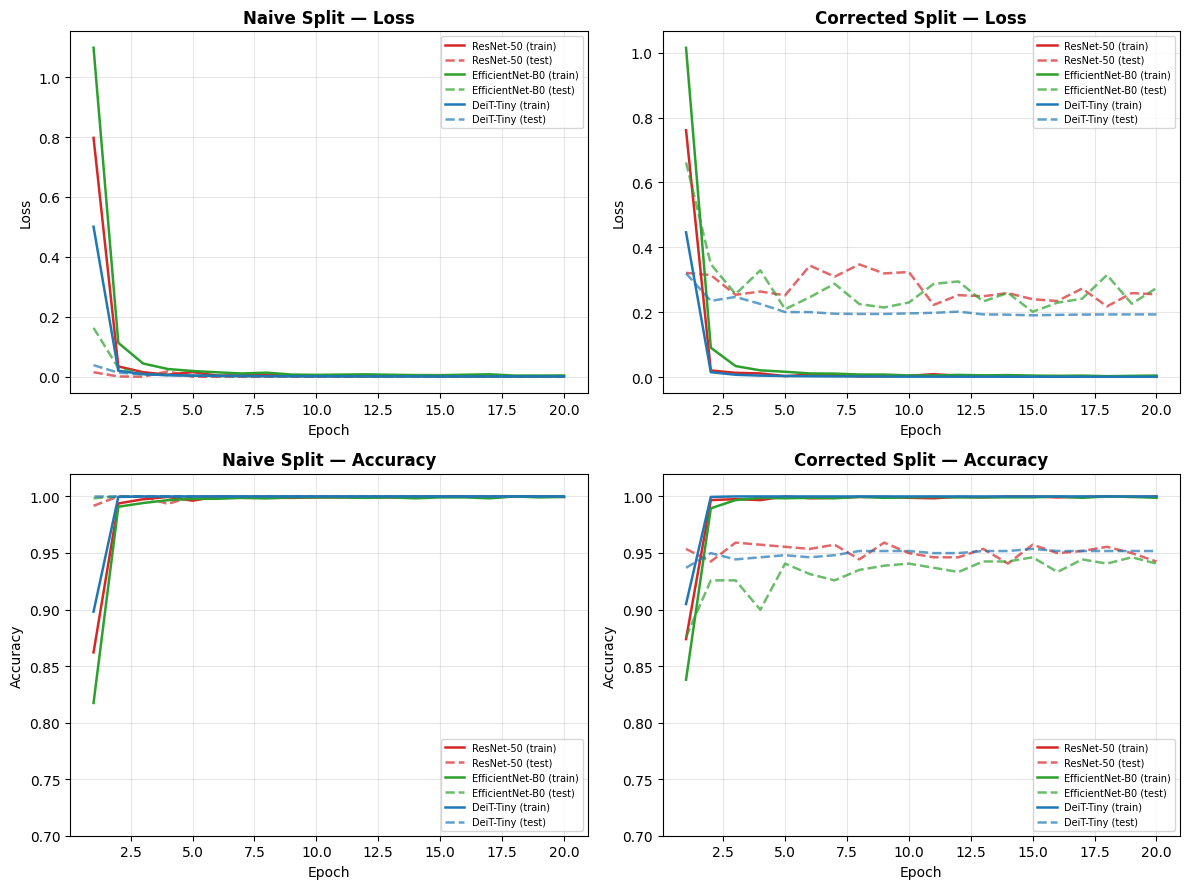

Saved: /content/drive/MyDrive/batik_classification_v2/figures/training_curves.png


In [ ]:
# Cell 11: Training Curves - demonstrate overfitting under naive split
import matplotlib.pyplot as plt

FIGURES_DIR = f'{PROJECT_DIR}/figures'

# Use seed=42 for representative curves (or you could average, but single seed is clearer)
REP_SEED = '42'

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

model_colors = {'resnet50': '#d62728', 'efficientnet_b0': '#2ca02c', 'deit_tiny': '#1f77b4'}
model_labels = {'resnet50': 'ResNet-50', 'efficientnet_b0': 'EfficientNet-B0', 'deit_tiny': 'DeiT-Tiny'}

for col, split_name in enumerate(['naive', 'corrected']):
    ax_loss = axes[0, col]
    ax_acc = axes[1, col]

    for model_name in ['resnet50', 'efficientnet_b0', 'deit_tiny']:
        if REP_SEED in results[split_name] and model_name in results[split_name][REP_SEED]:
            hist = results[split_name][REP_SEED][model_name]['history']
            epochs = range(1, len(hist['train_loss']) + 1)
            color = model_colors[model_name]
            label = model_labels[model_name]

            # Loss subplot
            ax_loss.plot(epochs, hist['train_loss'], color=color, linestyle='-',
                        label=f'{label} (train)', linewidth=1.8)
            ax_loss.plot(epochs, hist['test_loss'], color=color, linestyle='--',
                        label=f'{label} (test)', linewidth=1.8, alpha=0.7)

            # Accuracy subplot
            ax_acc.plot(epochs, hist['train_acc'], color=color, linestyle='-',
                       label=f'{label} (train)', linewidth=1.8)
            ax_acc.plot(epochs, hist['test_acc'], color=color, linestyle='--',
                       label=f'{label} (test)', linewidth=1.8, alpha=0.7)

    split_title = 'Naive Split' if split_name == 'naive' else 'Corrected Split'
    ax_loss.set_title(f'{split_title} — Loss', fontsize=12, fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=7, loc='upper right')
    ax_loss.grid(True, alpha=0.3)

    ax_acc.set_title(f'{split_title} — Accuracy', fontsize=12, fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_ylim(0.7, 1.02)
    ax_acc.legend(fontsize=7, loc='lower right')
    ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/training_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/training_curves.png")

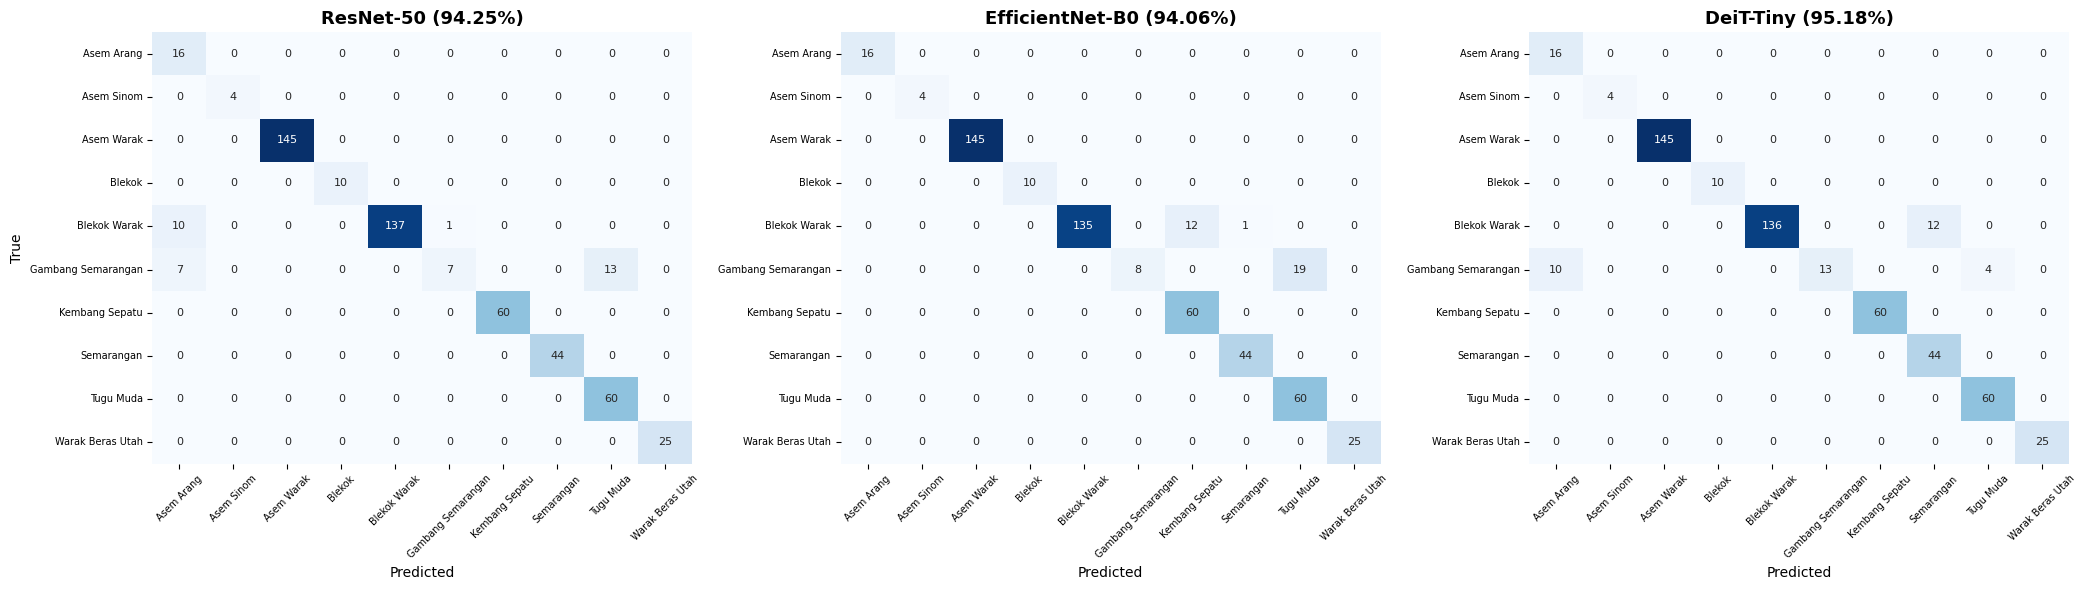

Saved: /content/drive/MyDrive/batik_classification_v2/figures/confusion_matrices.png


In [ ]:
# Cell 12: Confusion Matrices for all 3 models on corrected split (seed=42)
import seaborn as sns
from sklearn.metrics import confusion_matrix

REP_SEED = '42'

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for idx, model_name in enumerate(['resnet50', 'efficientnet_b0', 'deit_tiny']):
    r = results['corrected'][REP_SEED][model_name]
    preds = np.array(r['preds'])
    labels = np.array(r['labels'])
    acc = accuracy_score(labels, preds)

    cm = confusion_matrix(labels, preds)

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names_short, yticklabels=class_names_short,
                ax=ax, annot_kws={'size': 8})
    ax.set_title(f'{model_labels[model_name]} ({acc*100:.2f}%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    if idx == 0:
        ax.set_ylabel('True', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/confusion_matrices.png")

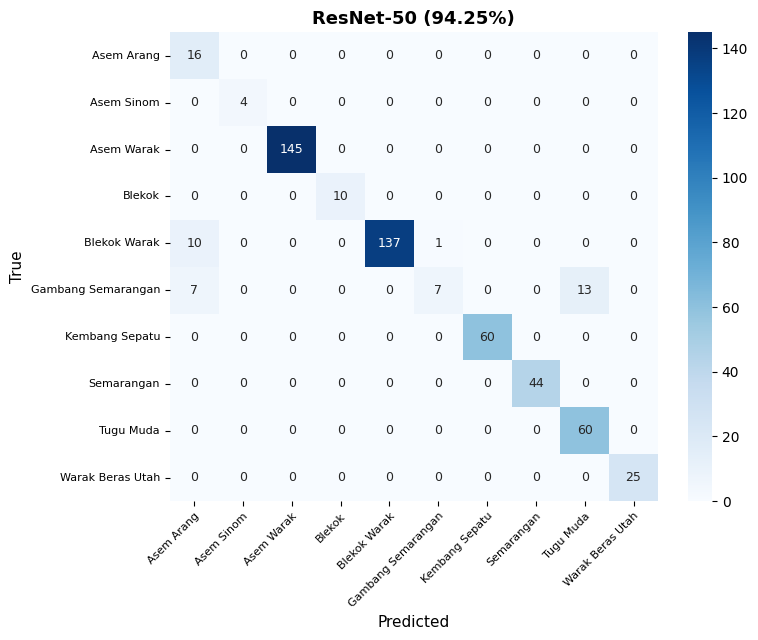

Saved: /content/drive/MyDrive/batik_classification_v2/figures/cm_resnet50.png


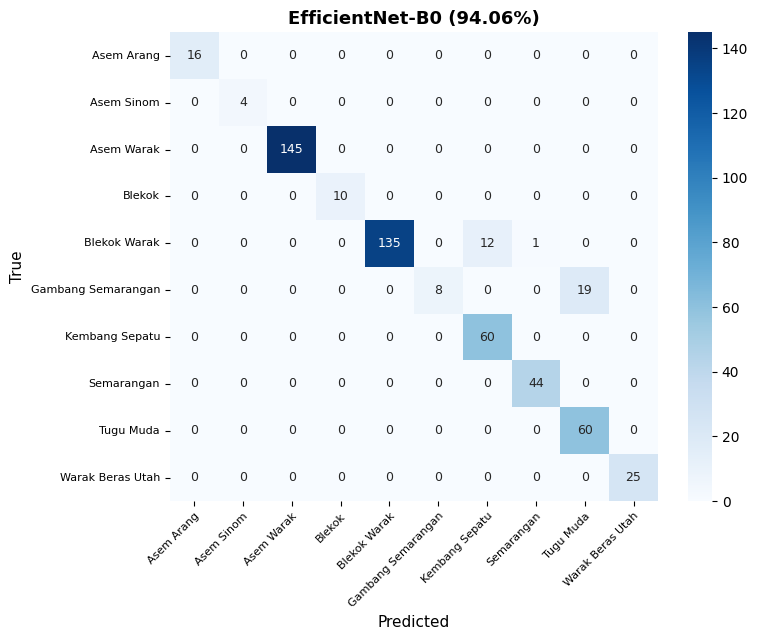

Saved: /content/drive/MyDrive/batik_classification_v2/figures/cm_efficientnet_b0.png


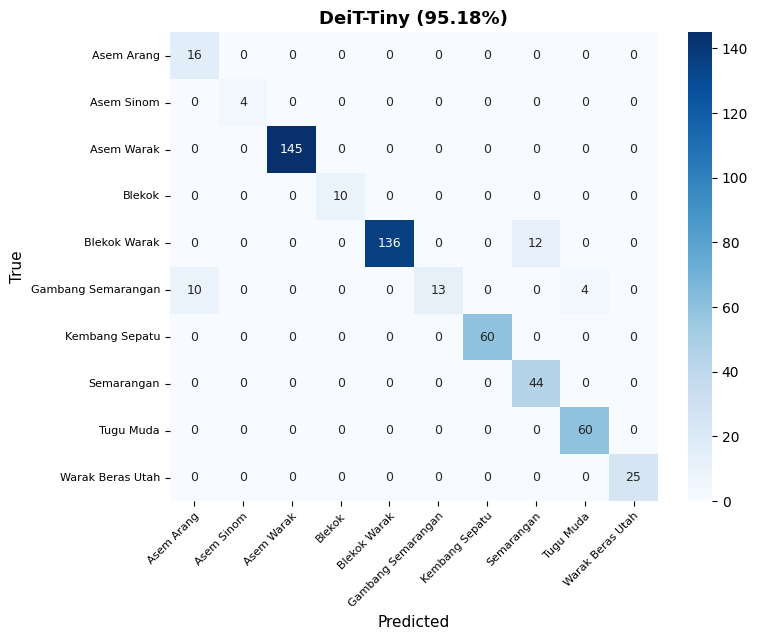

Saved: /content/drive/MyDrive/batik_classification_v2/figures/cm_deit_tiny.png


In [ ]:
# Cell 12 (revised): Save each confusion matrix as a separate image
import seaborn as sns
from sklearn.metrics import confusion_matrix

REP_SEED = '42'

for model_name in ['resnet50', 'efficientnet_b0', 'deit_tiny']:
    r = results['corrected'][REP_SEED][model_name]
    preds = np.array(r['preds'])
    labels = np.array(r['labels'])
    acc = accuracy_score(labels, preds)

    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=class_names_short, yticklabels=class_names_short,
                ax=ax, annot_kws={'size': 9})
    ax.set_title(f'{model_labels[model_name]} ({acc*100:.2f}%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

    # Right-align rotated x labels for readability
    plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')

    plt.tight_layout()
    out_path = f'{FIGURES_DIR}/cm_{model_name}.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out_path}")

[OK] Batik Cap Gambang Semarangan: using correctly classified sample -> Gambang Semarangan  (130).JPG
[OK] Batik Cap Asem Arang: using correctly classified sample -> asem arang (1).JPG


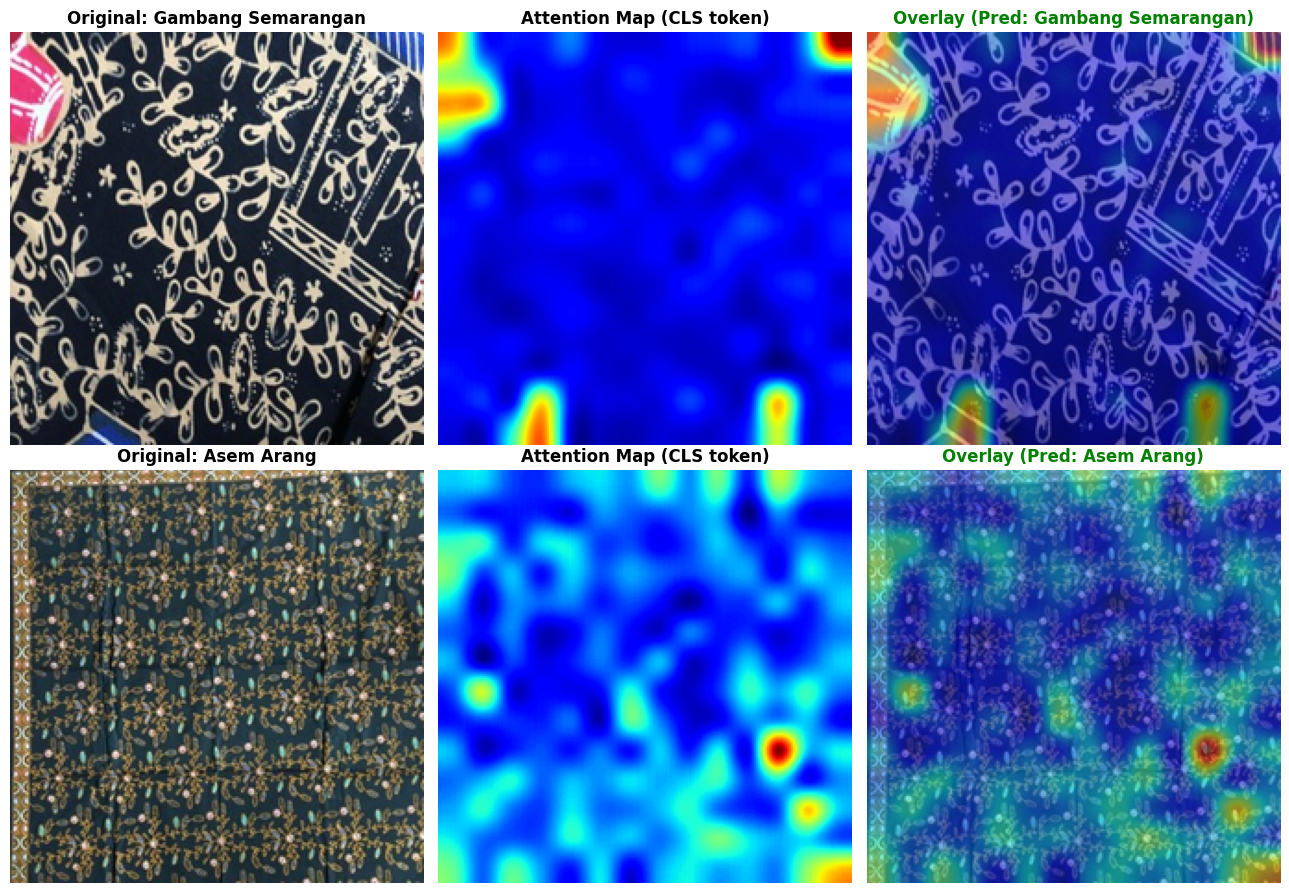


Saved attention_maps.png


In [ ]:
# Cell 13: Attention Visualization for DeiT-Tiny on confused classes
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

REP_SEED = '42'

# Load the trained DeiT-Tiny (seed=42, corrected split)
deit = create_deit_tiny().to(device)
deit.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/deit_corrected_s42.pth'))
deit.eval()

# Hook to capture attention weights from the last transformer block
attention_maps = []

def hook_fn(module, input, output):
    # For timm ViT, we hook the attention softmax
    pass

# timm's Attention module computes attention internally. We need to patch it
# to expose the attention weights. We'll use a forward hook on the attn drop.
def get_attention(model, img_tensor):
    """Extract attention from the last block's attention module."""
    attn_weights = {}

    def attn_hook(module, inp, out):
        # Recompute attention to capture weights
        B, N, C = inp[0].shape
        qkv = module.qkv(inp[0]).reshape(B, N, 3, module.num_heads, C // module.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * module.scale
        attn = attn.softmax(dim=-1)
        attn_weights['attn'] = attn.detach()

    # Register hook on the last block's attention
    last_block = model.blocks[-1]
    handle = last_block.attn.register_forward_hook(attn_hook)

    with torch.no_grad():
        _ = model(img_tensor)

    handle.remove()
    return attn_weights['attn']


def visualize_attention(img_path, true_label, save_name):
    """Generate attention overlay for a single image."""
    # Load and preprocess
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_tensor = eval_transform(img).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        out = deit(img_tensor)
        if isinstance(out, tuple):
            out = (out[0] + out[1]) / 2
        pred_idx = out.argmax(1).item()
    pred_label = class_names_short[pred_idx]

    # Get attention from last block
    attn = get_attention(deit, img_tensor)  # [B, heads, N, N]

    # DeiT distilled has 2 extra tokens: [cls, dist, patch_0, ..., patch_195]
    # Average over heads, take attention from CLS token (index 0) to patches
    attn_avg = attn[0].mean(0)  # [N, N] averaged over heads
    cls_attn = attn_avg[0, 2:]  # CLS token attention to patch tokens (skip cls + dist)

    # Reshape to spatial grid (14x14 for patch16 at 224)
    grid_size = int(np.sqrt(cls_attn.shape[0]))
    attn_grid = cls_attn.reshape(grid_size, grid_size).cpu().numpy()

    # Upsample to image size
    attn_map = Image.fromarray((attn_grid / attn_grid.max() * 255).astype(np.uint8))
    attn_map = attn_map.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)
    attn_map = np.array(attn_map) / 255.0

    return np.array(img_resized), attn_map, true_label, pred_label


# ============================================================
# Pick CORRECTLY CLASSIFIED sample images from the confused classes
# ============================================================
# Framing A: show a correctly classified example of each confused class,
# so the figure illustrates what the model attends to when it gets this
# hard pair RIGHT (rather than showcasing a failure case).
confused_classes = ['Batik Cap Gambang Semarangan', 'Batik Cap Asem Arang']

def predict_idx(img_path):
    """Return the model's predicted class index for one image."""
    img = Image.open(img_path).convert('RGB')
    img_tensor = eval_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = deit(img_tensor)
        if isinstance(out, tuple):
            out = (out[0] + out[1]) / 2
    return out.argmax(1).item()

samples = []
for cls in confused_classes:
    cls_idx = label_to_idx[cls]
    cls_test_files = [fp for fp, lbl in corrected_test_files if lbl == cls]

    # Find the FIRST correctly classified test image of this class.
    chosen = None
    for fp in cls_test_files:
        if predict_idx(fp) == cls_idx:
            chosen = fp
            break

    if chosen is not None:
        samples.append((chosen, cls.replace('Batik Cap ', ''), True))
        print(f"[OK] {cls}: using correctly classified sample -> {chosen.split('/')[-1]}")
    else:
        # Fallback: no correctly classified sample exists; use the first
        # and flag it honestly so the caption can reflect reality.
        samples.append((cls_test_files[0], cls.replace('Batik Cap ', ''), False))
        print(f"[WARN] {cls}: NO correctly classified test sample found; "
              f"using first sample (misclassified).")

# ============================================================
# Generate visualizations
# ============================================================
fig, axes = plt.subplots(len(samples), 3, figsize=(13, 4.5*len(samples)))
if len(samples) == 1:
    axes = axes.reshape(1, -1)

for row, (img_path, true_label, is_correct) in enumerate(samples):
    orig, attn_map, true_lbl, pred_lbl = visualize_attention(img_path, true_label, f'attn_{row}')

    # color the overlay title green if correct, red if not
    correct = (pred_lbl == true_lbl)
    overlay_color = 'green' if correct else 'red'

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'Original: {true_lbl}', fontsize=12, fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(attn_map, cmap='jet')
    axes[row, 1].set_title('Attention Map (CLS token)', fontsize=12, fontweight='bold')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(orig)
    axes[row, 2].imshow(attn_map, cmap='jet', alpha=0.5)
    axes[row, 2].set_title(f'Overlay (Pred: {pred_lbl})', fontsize=12,
                           fontweight='bold', color=overlay_color)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved attention_maps.png")

In [ ]:
# Cell 14: Prepare files for GitHub repository
import shutil

GITHUB_PREP_DIR = f'{PROJECT_DIR}/github_repo'
os.makedirs(GITHUB_PREP_DIR, exist_ok=True)
os.makedirs(f'{GITHUB_PREP_DIR}/splits', exist_ok=True)
os.makedirs(f'{GITHUB_PREP_DIR}/results', exist_ok=True)
os.makedirs(f'{GITHUB_PREP_DIR}/figures', exist_ok=True)

# Copy splits
for f in ['naive_train.csv', 'naive_test.csv', 'corrected_train.csv', 'corrected_test.csv']:
    shutil.copy(f'{PROJECT_DIR}/splits/{f}', f'{GITHUB_PREP_DIR}/splits/{f}')

# Copy results
for f in ['all_results.json', 'aggregated_metrics.json']:
    src = f'{PROJECT_DIR}/results/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'{GITHUB_PREP_DIR}/results/{f}')

# Copy figures
for f in os.listdir(f'{PROJECT_DIR}/figures'):
    if f.endswith('.png'):
        shutil.copy(f'{PROJECT_DIR}/figures/{f}', f'{GITHUB_PREP_DIR}/figures/{f}')

# ============================================================
# Build aggregated metrics summary CSV for the repo
# ============================================================
rows = []
for split_name in ['naive', 'corrected']:
    for model_name in model_names:
        agg = aggregate_seeds(split_name, model_name)
        if agg:
            rows.append({
                'split': split_name,
                'model': model_display[model_name],
                'params_M': round(agg['params']/1e6, 1),
                'n_seeds': agg['n_seeds'],
                'accuracy_mean': round(agg['accuracy_mean']*100, 2),
                'accuracy_std': round(agg['accuracy_std']*100, 2),
                'f1_macro_mean': round(agg['f1_macro_mean']*100, 2),
                'f1_macro_std': round(agg['f1_macro_std']*100, 2),
                'f1_weighted_mean': round(agg['f1_weighted_mean']*100, 2),
                'f1_weighted_std': round(agg['f1_weighted_std']*100, 2),
                'avg_epoch_sec': round(agg['avg_epoch_time_mean'], 1),
                'inference_fps': round(agg['fps_mean'], 1),
            })
pd.DataFrame(rows).to_csv(f'{GITHUB_PREP_DIR}/results/metrics_summary.csv', index=False)

print("Files prepared for GitHub:")
for root, dirs, files in os.walk(GITHUB_PREP_DIR):
    level = root.replace(GITHUB_PREP_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'{indent}  {f}')

Files prepared for GitHub:
github_repo/
  splits/
    naive_train.csv
    naive_test.csv
    corrected_train.csv
    corrected_test.csv
  results/
    all_results.json
    aggregated_metrics.json
    metrics_summary.csv
  figures/
    training_curves.png
    confusion_matrices.png
    cm_resnet50.png
    cm_efficientnet_b0.png
    cm_deit_tiny.png
    attention_maps.png
